In [1]:
import os
import subprocess
import sys

REPO_DIR = "/content/fitnova"
REPO_URL = "https://github.com/Ibrahim-Shahin1/fitnova.git"
BRANCH = "fresh-start"

if not os.path.isdir(REPO_DIR):
    print(f"Cloning {REPO_URL} (branch {BRANCH}) -> {REPO_DIR} ...")
    subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL, REPO_DIR], check=True)
else:
    print(f"Repo already at {REPO_DIR}; pulling latest from origin/{BRANCH} ...")
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "checkout", BRANCH], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only", "origin", BRANCH], check=True)

os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

_head = subprocess.run(
    ["git", "-C", REPO_DIR, "rev-parse", "--short", "HEAD"],
    capture_output=True, text=True, check=True,
).stdout.strip()
print(f"\nRepo ready: {REPO_DIR} @ {_head}")
print(f"sys.path[0]: {sys.path[0]}")
print(f"cwd: {os.getcwd()}")

for _m in [
    "backend/training/aqa/datasets/shallow_squat.py",
    "backend/training/aqa/datasets/cvcspc_ssl.py",
    "backend/training/aqa/harness/image_supervised_train.py",
    "backend/training/aqa/harness/cvcspc_pretrain.py",
]:
    print(f"  {'OK ' if os.path.isfile(_m) else 'MISSING'} {_m}")

Repo already at /content/fitnova; pulling latest from origin/fresh-start ...

Repo ready: /content/fitnova @ ade4c3e
sys.path[0]: /content/fitnova
cwd: /content/fitnova
  OK  backend/training/aqa/datasets/shallow_squat.py
  OK  backend/training/aqa/datasets/cvcspc_ssl.py
  OK  backend/training/aqa/harness/image_supervised_train.py
  OK  backend/training/aqa/harness/cvcspc_pretrain.py


In [2]:
from backend.training.aqa.harness import _envinit  # CUBLAS_WORKSPACE_CONFIG before torch

import importlib.metadata
import os
import shutil
import sys

for _pkg in ["torch", "torchvision", "scikit-learn", "numpy", "tqdm"]:
    print(f"  {_pkg:<14} {importlib.metadata.version(_pkg)}")

import torch
import torchvision

print("\npython     :", sys.version.split()[0])
print("torch      :", torch.__version__)
print("torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUBLAS_WORKSPACE_CONFIG:", os.environ.get("CUBLAS_WORKSPACE_CONFIG"))

assert torch.cuda.is_available(), (
    "GPU required — Runtime > Change runtime type > Hardware accelerator: L4 (T4 also fine)"
)
print(f"GPU: {torch.cuda.get_device_name(0)} "
      f"({torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB)")

from backend.training.aqa.harness.colab import mount_drive, stage_shallow_squat_images

MYDRIVE = mount_drive()
DRIVE_ROOT_3001 = MYDRIVE  # consolidated Drive root

_expected = os.path.join(
    DRIVE_ROOT_3001,
    "Fitness-AQA_dataset_release/Squat/Labeled_Dataset/Shallow_Squat_Error_Dataset/images.zip",
)
print(f"\nimages.zip on Drive: {'FOUND' if os.path.isfile(_expected) else 'NOT FOUND'}\n  {_expected}")

SHALLOW_ROOT = stage_shallow_squat_images(DRIVE_ROOT_3001, local_root="/content/squat_shallow_images")
IMAGES_ROOT = os.path.join(SHALLOW_ROOT, "crops_unaligned")
LABELS_PATH = os.path.join(SHALLOW_ROOT, "labels_shallow_depth.json")
SPLITS_ROOT = os.path.join(SHALLOW_ROOT, "splits")

_n_jpg = sum(1 for _r, _d, _fs in os.walk(IMAGES_ROOT) for _f in _fs if _f.endswith(".jpg"))
print(f"\nstaged: {_n_jpg} jpgs at {IMAGES_ROOT}")
print(f"labels: {'OK' if os.path.isfile(LABELS_PATH) else 'MISSING'}   "
      f"splits: {'OK' if os.path.isdir(SPLITS_ROOT) else 'MISSING'}")
print(f"free disk on /content: {shutil.disk_usage('/content').free / 1e9:.1f} GB")

  torch          2.11.0+cu128
  torchvision    0.26.0+cu128
  scikit-learn   1.6.1
  numpy          2.0.2
  tqdm           4.67.3

python     : 3.12.13
torch      : 2.11.0+cu128
torchvision: 0.26.0+cu128
CUDA available: True
CUBLAS_WORKSPACE_CONFIG: :4096:8
GPU: NVIDIA L4 (23.7 GB)

images.zip on Drive: FOUND
  /content/drive/MyDrive/Fitness-AQA_dataset_release/Squat/Labeled_Dataset/Shallow_Squat_Error_Dataset/images.zip

staged: 3738 jpgs at /content/squat_shallow_images/crops_unaligned
labels: OK   splits: OK
free disk on /content: 201.0 GB


train: 2542 crops (expected 2542)  pos=1099 (43.2%)  OK
val  :  529 crops (expected 529)  pos=249 (47.1%)  OK
test :  540 crops (expected 540)  pos=236 (43.7%)  OK

pos_weight (1,): 1.3130
train batch: imgs (32, 3, 224, 224) torch.float32, labels (32,) torch.float32, label values [0, 1]


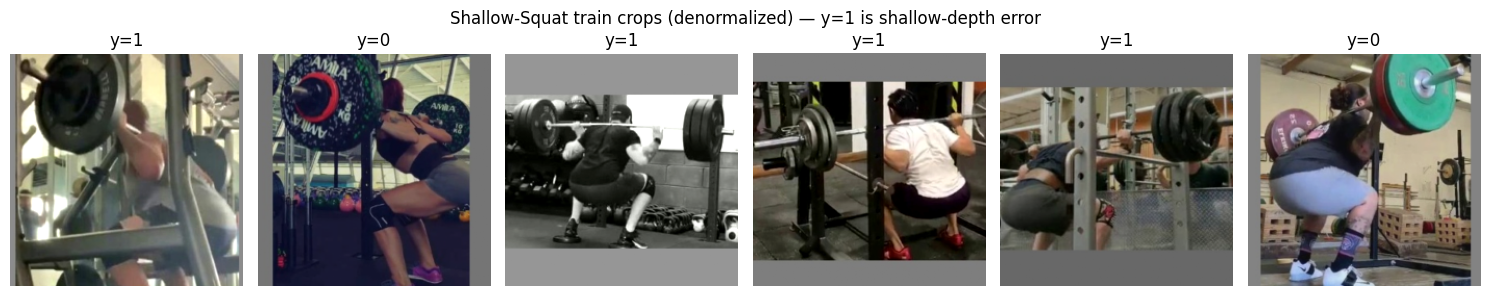

In [3]:
import torch
import matplotlib.pyplot as plt

from backend.training.aqa.datasets.shallow_squat import (
    IMAGENET_MEAN,
    IMAGENET_STD,
    build_loaders,
)

loaders = build_loaders(
    images_root=IMAGES_ROOT, labels_path=LABELS_PATH, splits_root=SPLITS_ROOT,
    batch_size=32, num_workers=2,
)

_EXPECT = {"train": 2542, "val": 529, "test": 540}
for _split, _exp in _EXPECT.items():
    _ds = loaders[_split].dataset
    _pos = sum(_lbl for _, _lbl in _ds.records)
    print(f"{_split:5s}: {len(_ds):4d} crops (expected {_exp})  pos={_pos} "
          f"({100 * _pos / len(_ds):.1f}%)  {'OK' if len(_ds) == _exp else 'MISMATCH'}")

_pw = loaders["train"].dataset.pos_weight
print(f"\npos_weight {tuple(_pw.shape)}: {float(_pw[0]):.4f}")
assert tuple(_pw.shape) == (1,), "pos_weight must be single-head (1,)"

_imgs, _labels = next(iter(loaders["train"]))
print(f"train batch: imgs {tuple(_imgs.shape)} {_imgs.dtype}, "
      f"labels {tuple(_labels.shape)} {_labels.dtype}, "
      f"label values {sorted(set(int(_x) for _x in _labels.tolist()))}")
assert _imgs.shape[1:] == (3, 224, 224) and _imgs.dtype == torch.float32
assert _labels.ndim == 1, f"label batch must be (B,) single-head, got {tuple(_labels.shape)}"

_mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
_std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for _i, _ax in enumerate(axes):
    _crop = (_imgs[_i] * _std + _mean).clamp(0, 1).permute(1, 2, 0).numpy()
    _ax.imshow(_crop)
    _ax.set_title(f"y={int(_labels[_i])}")
    _ax.axis("off")
plt.suptitle("Shallow-Squat train crops (denormalized) — y=1 is shallow-depth error")
plt.tight_layout()
plt.show()

In [4]:
import torch.nn as nn

from backend.training.aqa.harness.image_supervised_train import build_resnet18

_device = torch.device("cuda")
_model = build_resnet18().to(_device)
assert isinstance(_model.fc, nn.Linear) and _model.fc.out_features == 1, "head must be Linear(512, 1)"
with torch.no_grad():
    _probe = _model(torch.zeros(2, 3, 224, 224, device=_device))
print("head:", _model.fc, "| forward zeros[2,3,224,224] ->", tuple(_probe.shape))
assert tuple(_probe.shape) == (2, 1), f"expected [2,1], got {tuple(_probe.shape)}"

torch.cuda.reset_peak_memory_stats()
_imgs, _labels = next(iter(loaders["train"]))
_target = _labels.view(-1, 1).to(_device)
_crit = nn.BCEWithLogitsLoss(pos_weight=_pw.to(_device))
_logits = _model(_imgs.to(_device))
_loss = _crit(_logits, _target)
_loss.backward()
_peak_gb = torch.cuda.max_memory_allocated() / 1e9
_total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"forward+backward batch {_imgs.shape[0]}: loss={_loss.item():.4f}, "
      f"peak VRAM={_peak_gb:.2f} GB / {_total_gb:.1f} GB")
assert _peak_gb < _total_gb, "VRAM exceeded — drop batch_size"

del _model, _logits, _loss
torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 241MB/s]


head: Linear(in_features=512, out_features=1, bias=True) | forward zeros[2,3,224,224] -> (2, 1)
forward+backward batch 32: loss=0.9179, peak VRAM=0.86 GB / 23.7 GB


In [5]:
import os as _os
import time

from backend.training.aqa.datasets.shallow_squat import ShallowSquatDataset
from backend.training.aqa.harness.image_supervised_train import ImageConfig, run_image_epoch

_cfg = ImageConfig()
print("ImageConfig:", _cfg)

_t0 = time.perf_counter()
_res = run_image_epoch(
    run_name="shallow_squat_baseline_seed42_timing",
    drive_root=MYDRIVE,
    images_root=IMAGES_ROOT, labels_path=LABELS_PATH, splits_root=SPLITS_ROOT,
    seed=42, config=_cfg, resume=False, max_epochs=1,
    dataset_cls=ShallowSquatDataset,
)
_wall = time.perf_counter() - _t0
_m0 = _res["metrics_history"][0]
_epoch_s = _m0["epoch_wall_time_s"]
print(f"\nepoch-0 time: {_epoch_s:.1f}s ({_epoch_s / 60:.1f} min)  |  cell wall incl setup: {_wall:.1f}s")
print(f"estimated full run ({_cfg.max_epochs} ep): {_epoch_s * _cfg.max_epochs / 3600:.2f} h")
print(f"epoch-0 train_loss={_m0['train_loss_mean']:.4f}  "
      f"val_f1={_m0['val_f1']:.4f}  val_pr_auc={_m0['val_pr_auc']:.4f}")

_ck = torch.load(_res["checkpoint_path"], map_location="cpu", weights_only=False)
print(f"\ncheckpoint: {_os.path.basename(_res['checkpoint_path'])}  "
      f"code_version={_ck['code_version']}")
print("payload keys:", sorted(_ck.keys()))
assert _ck["code_version"] == "phase07-image-baseline"

ImageConfig: ImageConfig(learning_rate=0.0001, weight_decay=0.0, batch_size=32, num_workers=4, max_epochs=50, early_stop_patience=8, scheduler_name='cosine', scheduler_t_max=50, model_arch='resnet18_imagenet_v1', loss_name='BCEWithLogitsLoss(pos_weight=dataset.pos_weight)')



epoch-0 time: 6.1s (0.1 min)  |  cell wall incl setup: 7.4s
estimated full run (50 ep): 0.08 h
epoch-0 train_loss=0.4930  val_f1=0.7875  val_pr_auc=0.9068

checkpoint: epoch_000.pt  code_version=phase07-image-baseline
payload keys: ['best_f1_val', 'best_thresholds', 'code_version', 'config_hash', 'config_repr', 'epoch', 'metrics_history', 'model_state_dict', 'optimizer_state_dict', 'rng_state', 'scheduler_state_dict']


In [3]:
import logging

from backend.training.aqa.datasets.shallow_squat import ShallowSquatDataset
from backend.training.aqa.harness.image_supervised_train import ImageConfig, run_image_epoch

logging.basicConfig(level=logging.WARNING, format="%(message)s", force=True)
logging.getLogger("aqa.phase07").setLevel(logging.INFO)

SEEDS = [42, 1337, 7]
_results = {}

_n = 42
_results[_n] = run_image_epoch(
    run_name=f"shallow_squat_baseline_seed{_n}",
    drive_root=MYDRIVE,
    images_root=IMAGES_ROOT, labels_path=LABELS_PATH, splits_root=SPLITS_ROOT,
    seed=_n, config=ImageConfig(), resume=True, max_epochs=50,
    dataset_cls=ShallowSquatDataset,
)
_r = _results[_n]
print(f"\nseed {_n}: best_f1_val={_r['best_f1_val']:.4f}  (last epoch {_r['epoch']})")
print(f"best.pt: {_r['best_checkpoint_path']}")

run_dir: /content/drive/MyDrive/FitNova/checkpoints/phase07/shallow_squat_baseline_seed42 (config_hash=402ca64442078859)
pos_weight from train (N=2542): pos=1099 -> w=1.3130
ShallowSquatDataset[train]: 2542 records
pos_weight from train (N=2542): pos=1099 -> w=1.3130
ShallowSquatDataset[val]: 529 records
pos_weight from train (N=2542): pos=1099 -> w=1.3130
ShallowSquatDataset[test]: 540 records
Model: ResNet-18 + Linear(512, 1) head, 11177025 params
Resumed epoch_004.pt; start_epoch=5 best_f1_val=0.8500


epoch=5 val_loss=0.503642 val_f1=0.8271 val_pr_auc=0.9378 wall=6.5s


epoch=6 val_loss=0.448841 val_f1=0.8543 val_pr_auc=0.9292 wall=5.5s
New best val_f1=0.8543 -> wrote best.pt


epoch=7 val_loss=0.420905 val_f1=0.8740 val_pr_auc=0.9328 wall=5.5s
New best val_f1=0.8740 -> wrote best.pt


epoch=8 val_loss=0.437564 val_f1=0.8710 val_pr_auc=0.9433 wall=5.6s


...

epoch=15 val_loss=0.367990 val_f1=0.8566 val_pr_auc=0.9521 wall=5.5s


epoch=16 val_loss=0.377911 val_f1=0.8577 val_pr_auc=0.9497 wall=5.6s


epoch=17 val_loss=0.406187 val_f1=0.8583 val_pr_auc=0.9495 wall=5.5s


epoch=18 val_loss=0.449636 val_f1=0.8266 val_pr_auc=0.9471 wall=5.6s
Early stopping at epoch 18 (best=0.8760 after 8 without improvement)



seed 42: best_f1_val=0.8760  (last epoch 18)
best.pt: /content/drive/MyDrive/FitNova/checkpoints/phase07/shallow_squat_baseline_seed42/best.pt


In [4]:
for _n in SEEDS[1:]:
    print(f"\n===== seed {_n} =====")
    _results[_n] = run_image_epoch(
        run_name=f"shallow_squat_baseline_seed{_n}",
        drive_root=MYDRIVE,
        images_root=IMAGES_ROOT, labels_path=LABELS_PATH, splits_root=SPLITS_ROOT,
        seed=_n, config=ImageConfig(), resume=True, max_epochs=50,
        dataset_cls=ShallowSquatDataset,
    )

print("\n\nper-seed best val F1 (0.5 proxy):")
for _n in SEEDS:
    print(f"  seed {_n:5d}: best_f1_val={_results[_n]['best_f1_val']:.4f}  "
          f"(last epoch {_results[_n]['epoch']})")

run_dir: /content/drive/MyDrive/FitNova/checkpoints/phase07/shallow_squat_baseline_seed1337 (config_hash=0e3a534a23f212ac)
pos_weight from train (N=2542): pos=1099 -> w=1.3130
ShallowSquatDataset[train]: 2542 records
pos_weight from train (N=2542): pos=1099 -> w=1.3130
ShallowSquatDataset[val]: 529 records
pos_weight from train (N=2542): pos=1099 -> w=1.3130
ShallowSquatDataset[test]: 540 records



===== seed 1337 =====


Model: ResNet-18 + Linear(512, 1) head, 11177025 params


epoch=0 val_loss=0.436255 val_f1=0.8185 val_pr_auc=0.9004 wall=6.0s
New best val_f1=0.8185 -> wrote best.pt


epoch=1 val_loss=0.591254 val_f1=0.7885 val_pr_auc=0.8909 wall=5.5s


...

epoch=20 val_loss=0.425449 val_f1=0.8646 val_pr_auc=0.9391 wall=5.5s


epoch=21 val_loss=0.430375 val_f1=0.8588 val_pr_auc=0.9386 wall=5.6s


epoch=22 val_loss=0.455277 val_f1=0.8651 val_pr_auc=0.9409 wall=5.5s


epoch=23 val_loss=0.455217 val_f1=0.8677 val_pr_auc=0.9415 wall=5.5s
Early stopping at epoch 23 (best=0.8845 after 8 without improvement)




per-seed best val F1 (0.5 proxy):
  seed    42: best_f1_val=0.8760  (last epoch 18)
  seed  1337: best_f1_val=0.8715  (last epoch 20)
  seed     7: best_f1_val=0.8845  (last epoch 23)


In [5]:
import numpy as np
import torch
from torch.utils.data import DataLoader

from backend.training.aqa.datasets.shallow_squat import ShallowSquatDataset
from backend.training.aqa.eval.metrics import (
    confusion_matrix_per_error,
    f1_per_error,
    pr_auc_per_error,
    threshold_sweep,
)
from backend.training.aqa.harness.image_supervised_train import build_resnet18

_device = torch.device("cuda")


def _split_loader(split):
    ds = ShallowSquatDataset(
        split=split, images_root=IMAGES_ROOT, labels_path=LABELS_PATH,
        splits_root=SPLITS_ROOT, train_aug=False,
    )
    return DataLoader(ds, batch_size=64, shuffle=False, num_workers=0)


@torch.no_grad()
def _gather(model, loader):
    model.eval()
    scs, lbs = [], []
    for _img, _lbl in loader:
        scs.append(torch.sigmoid(model(_img.to(_device))).squeeze(-1).cpu())
        lbs.append(_lbl)
    return torch.cat(scs).numpy(), torch.cat(lbs).numpy().astype(int)


_val_loader, _test_loader = _split_loader("val"), _split_loader("test")
_per_seed_val, _per_seed_test = {}, {}
_val_labels = _test_labels = None
for _n in SEEDS:
    _ck = torch.load(
        f"{MYDRIVE}/FitNova/checkpoints/phase07/shallow_squat_baseline_seed{_n}/best.pt",
        map_location=_device, weights_only=False,
    )
    _m = build_resnet18().to(_device)
    _m.load_state_dict(_ck["model_state_dict"])
    _per_seed_val[_n], _val_labels = _gather(_m, _val_loader)
    _per_seed_test[_n], _test_labels = _gather(_m, _test_loader)
    print(f"seed {_n:5d}: val F1@0.5={f1_per_error(_val_labels, (_per_seed_val[_n] >= 0.5).astype(int)):.4f}  "
          f"test F1@0.5={f1_per_error(_test_labels, (_per_seed_test[_n] >= 0.5).astype(int)):.4f}")
    del _m
    torch.cuda.empty_cache()

_ens_val = np.mean([_per_seed_val[_n] for _n in SEEDS], axis=0)
_ens_test = np.mean([_per_seed_test[_n] for _n in SEEDS], axis=0)
_t_star, _f1_val_at_t = threshold_sweep(_val_labels, _ens_val)

_test_pred = (_ens_test >= _t_star).astype(int)
_test_f1 = f1_per_error(_test_labels, _test_pred)
_test_pr_auc = pr_auc_per_error(_test_labels, _ens_test)
_test_cm = confusion_matrix_per_error(_test_labels, _test_pred)
_best_seed = max(SEEDS, key=lambda n: f1_per_error(_val_labels, (_per_seed_val[n] >= 0.5).astype(int)))
_best_seed_test_f1 = f1_per_error(_test_labels, (_per_seed_test[_best_seed] >= _t_star).astype(int))

print(f"\nensemble val F1@0.5={f1_per_error(_val_labels, (_ens_val >= 0.5).astype(int)):.4f}  "
      f"|  val-tuned t*={_t_star:.4f} (ensemble val F1@t*={_f1_val_at_t:.4f})")
print("=" * 60)
print("Shallow-Squat SUPERVISED BASELINE  (SSL-lift control)")
print("=" * 60)
print(f"  ensemble ({len(SEEDS)} seeds) test F1 @ t*={_t_star:.3f} : {_test_f1:.4f}")
print(f"  ensemble test PR-AUC (threshold-free)   : {_test_pr_auc:.4f}")
print(f"  single best-val seed ({_best_seed}) test F1     : {_best_seed_test_f1:.4f}")
print(f"  confusion [[TN,FP],[FN,TP]]:\n{_test_cm}")
print("-" * 60)
print("  paper rows (context — NO supervised-ImageNet row exists):")
print("    CVCSPC (SSL target)         : 0.8694")
print("    SimSiam (image SSL)         : 0.8286")
print("    OpenPose-TDM (2D pose)      : 0.8340")

pos_weight from train (N=2542): pos=1099 -> w=1.3130
ShallowSquatDataset[val]: 529 records
pos_weight from train (N=2542): pos=1099 -> w=1.3130
ShallowSquatDataset[test]: 540 records
Model: ResNet-18 + Linear(512, 1) head, 11177025 params


seed    42: val F1@0.5=0.8760  test F1@0.5=0.8708


Model: ResNet-18 + Linear(512, 1) head, 11177025 params


seed  1337: val F1@0.5=0.8715  test F1@0.5=0.8541


Model: ResNet-18 + Linear(512, 1) head, 11177025 params


seed     7: val F1@0.5=0.8845  test F1@0.5=0.8838

ensemble val F1@0.5=0.8848  |  val-tuned t*=0.4734 (ensemble val F1@t*=0.8942)
Shallow-Squat SUPERVISED BASELINE  (SSL-lift control)
  ensemble (3 seeds) test F1 @ t*=0.473 : 0.8750
  ensemble test PR-AUC (threshold-free)   : 0.9506
  single best-val seed (7) test F1     : 0.8784
  confusion [[TN,FP],[FN,TP]]:
[[270  34]
 [ 26 210]]
------------------------------------------------------------
  paper rows (context — NO supervised-ImageNet row exists):
    CVCSPC (Plan-04 SSL target) : 0.8694
    SimSiam (image SSL)         : 0.8286
    OpenPose-TDM (2D pose)      : 0.8340
